In [14]:
import pandas as pd

ft = pd.read_csv('/content/boston.csv')
data = ft.copy()

In [15]:
data.isnull().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
sns.set(style='whitegrid')
plt.figure(figsize=(200,150))
sns.barplot(data=data,x='age',y='tax',palette='rainbow')
plt.title('age vs tax',fontsize=16)
plt.xlabel('age',fontsize=14)
plt.ylabel('tax',fontsize=14)
plt.show()

/tmp/ipykernel_637/197289722.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data,x='age',y='tax',palette='rainbow')


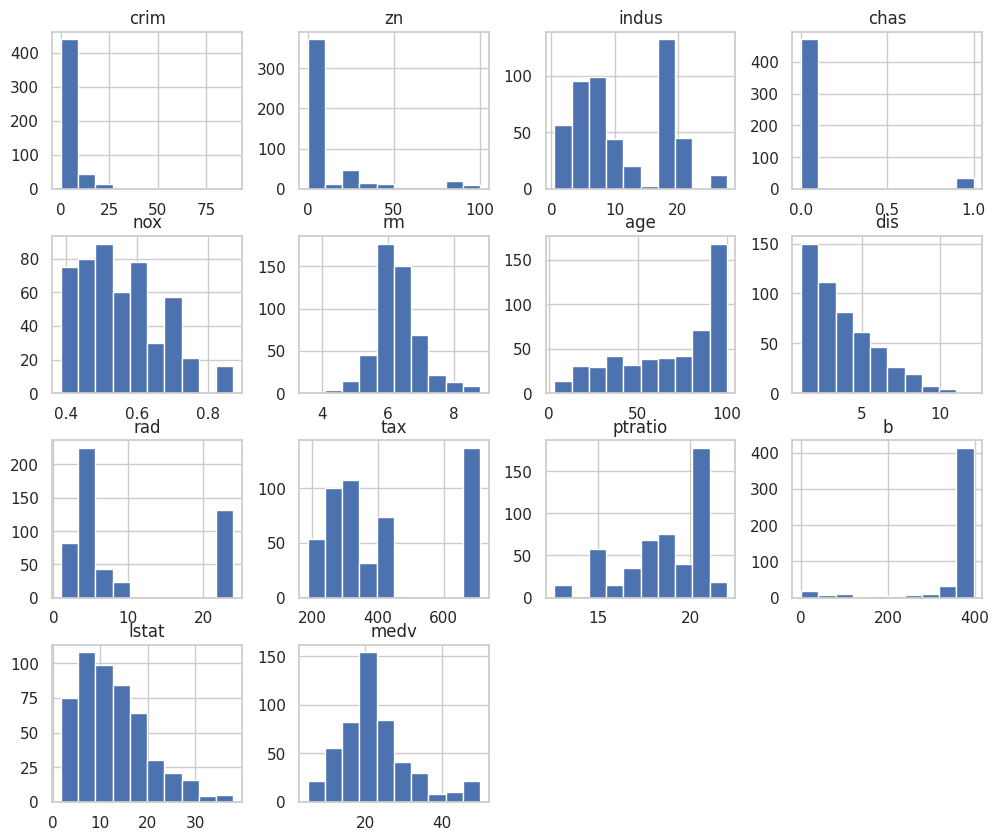

In [18]:
data.hist(figsize=(12,10))
plt.show()

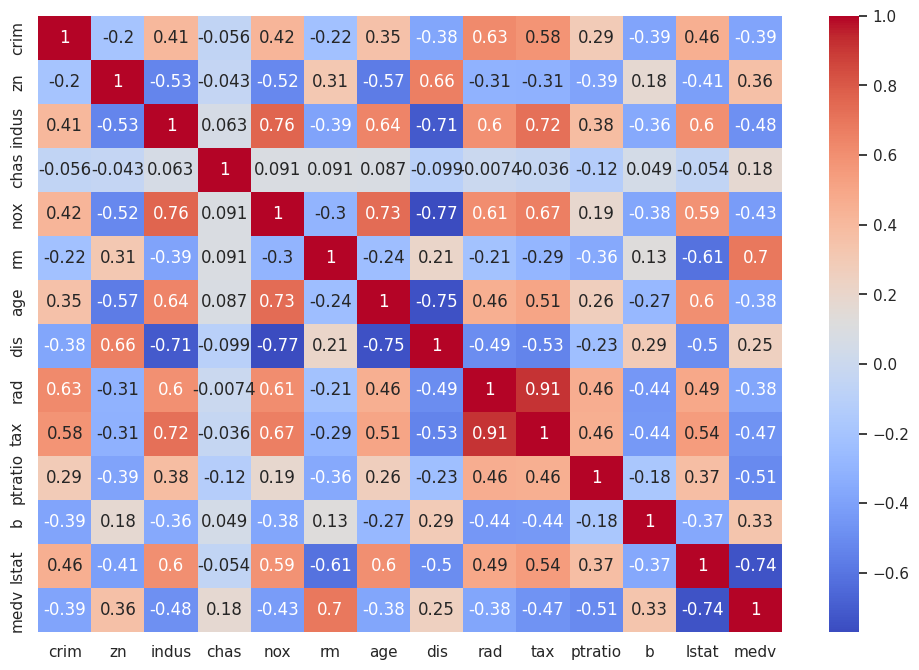

In [19]:
plt.figure(figsize=(12,8))

sns.heatmap(data.corr(), annot=True, cmap='coolwarm')

plt.show()

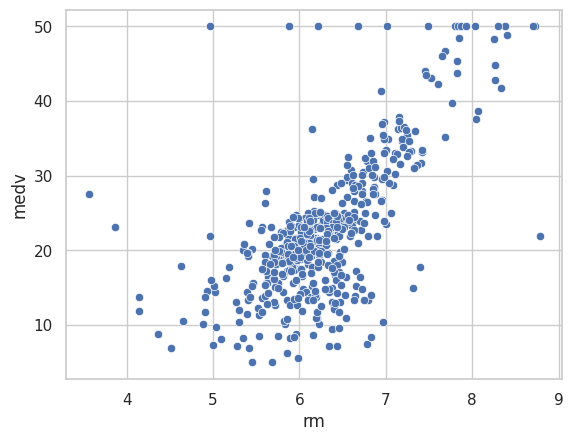

In [20]:
sns.scatterplot(x='rm', y='medv', data=data)

plt.show()

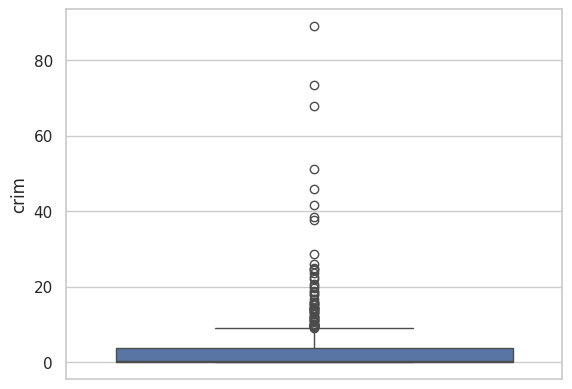

In [21]:
sns.boxplot(data['crim'])

plt.show()

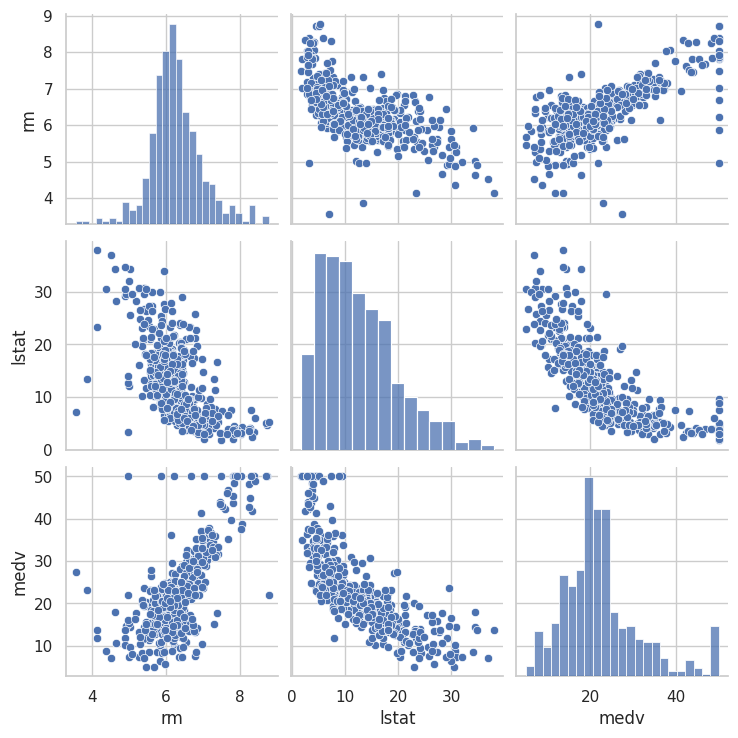

In [22]:
sns.pairplot(data[['rm','lstat','medv']])

plt.show()

In [22]:
'''from sklearn.preprocessing import StandardScaler

# Features
X = data.drop('medv', axis=1)

# Initialize scaler
scaler = StandardScaler()

# Scale features
X_scaled = scaler.fit_transform(X)'''

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = data.drop(columns=["medv"])  # All columns except target
y = data["medv"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.6688
RMSE: 4.9286
